In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np 
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Flatten, Activation, GlobalMaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.xception import Xception, preprocess_input

from sklearn.model_selection import train_test_split

import kagglehub

# Download the latest dataset version (optional, Kaggle provides dataset)
path = kagglehub.dataset_download("kmader/rsna-bone-age")
print("Path to dataset files:", path)

dataframe_direction = "/kaggle/input/rsna-bone-age"
print(os.listdir(dataframe_direction))


2025-10-04 06:21:32.611344: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759558892.792995      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759558892.841010      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Path to dataset files: /kaggle/input/rsna-bone-age
['boneage-training-dataset.csv', 'boneage-training-dataset', 'boneage-test-dataset', 'boneage-test-dataset.csv']


In [2]:
training_dataframe = pd.read_csv(os.path.join(dataframe_direction, "boneage-training-dataset.csv"))
training_dataframe["path"] = training_dataframe["id"].map(lambda x: os.path.join(dataframe_direction, "boneage-training-dataset", "boneage-training-dataset", f"{x}.png"))

training_dataframe["imagepath"] = training_dataframe["id"].map(lambda x: f"{x}.png")
training_dataframe["gender"] = training_dataframe["male"].map(lambda x: "male" if x else "female")
training_dataframe["gender_encoded"] = training_dataframe["gender"].map(lambda x: 1 if x == "male" else 0)
training_dataframe["boneage_category"] = pd.cut(training_dataframe["boneage"], 10)

boneage_std = 2 * training_dataframe["boneage"].std()
boneage_mean = training_dataframe["boneage"].mean()
training_dataframe["norm_age"] = (training_dataframe["boneage"] - boneage_mean) / boneage_std

print(training_dataframe.head())


     id  boneage   male                                               path  \
0  1377      180  False  /kaggle/input/rsna-bone-age/boneage-training-d...   
1  1378       12  False  /kaggle/input/rsna-bone-age/boneage-training-d...   
2  1379       94  False  /kaggle/input/rsna-bone-age/boneage-training-d...   
3  1380      120   True  /kaggle/input/rsna-bone-age/boneage-training-d...   
4  1381       82  False  /kaggle/input/rsna-bone-age/boneage-training-d...   

  imagepath  gender  gender_encoded boneage_category  norm_age  
0  1377.png  female               0   (159.9, 182.6]  0.639590  
1  1378.png  female               0    (0.773, 23.7] -1.400135  
2  1379.png  female               0    (91.8, 114.5] -0.404555  
3  1380.png    male               1   (114.5, 137.2] -0.088883  
4  1381.png  female               0     (69.1, 91.8] -0.550249  


In [3]:
testing_dataframe = pd.read_csv(os.path.join(dataframe_direction, "boneage-test-dataset.csv"))
testing_dataframe["path"] = testing_dataframe["Case ID"].map(lambda x: os.path.join(dataframe_direction, "boneage-test-dataset", "boneage-test-dataset", f"{x}.png"))
testing_dataframe["imagepath"] = testing_dataframe["Case ID"].map(lambda x: f"{x}.png")
testing_dataframe["gender"] = testing_dataframe["Sex"].map(lambda x: "male" if x == "M" else "female")

print(testing_dataframe.head())


   Case ID Sex                                               path imagepath  \
0     4360   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4360.png   
1     4361   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4361.png   
2     4362   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4362.png   
3     4363   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4363.png   
4     4364   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4364.png   

  gender  
0   male  
1   male  
2   male  
3   male  
4   male  


TRAIN

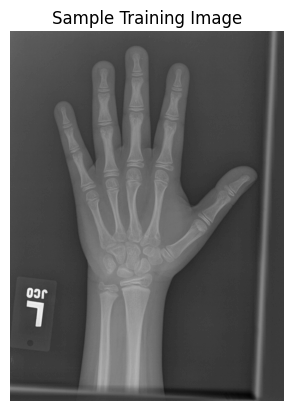

In [4]:
single_img = training_dataframe["path"].iloc[5]
img = imread(single_img)
plt.imshow(img, cmap="gray")
plt.title("Sample Training Image")
plt.axis('off')
plt.show()


In [5]:
df_train, df_val = train_test_split(training_dataframe, test_size=0.2, random_state=42, shuffle=True)
valid_df, df_test = train_test_split(df_val, test_size=0.5, random_state=42, shuffle=True)

data_augmentation = dict(rotation_range=180,
                        zoom_range=0.25,
                        brightness_range=[0.2, 0.5],
                        width_shift_range=0.2,
                        height_shift_range=0.2,
                        horizontal_flip=True,
                        shear_range=0.05,
                        fill_mode="nearest")

train_generator = ImageDataGenerator(rescale=1/255, preprocessing_function=preprocess_input, **data_augmentation)
test_val_generator = ImageDataGenerator(rescale=1/255, preprocessing_function=preprocess_input)

img_size = (256, 256)
batch_size = 32


In [6]:
train_data = train_generator.flow_from_dataframe(
    dataframe=df_train,
    x_col="path",
    y_col="boneage",
    batch_size=batch_size,
    seed=42,
    shuffle=True,
    class_mode="other",
    flip_vertical=True,
    color_mode="rgb",
    target_size=img_size
)

valid_data = test_val_generator.flow_from_dataframe(
    dataframe=valid_df,
    x_col="path",
    y_col="boneage",
    batch_size=batch_size,
    seed=42,
    shuffle=True,
    class_mode="other",
    flip_vertical=True,
    color_mode="rgb",
    target_size=img_size
)

test_data = test_val_generator.flow_from_dataframe(
    dataframe=df_test,
    x_col="path",
    y_col="boneage",
    batch_size=batch_size,
    seed=42,
    shuffle=True,
    class_mode="other",
    flip_vertical=True,
    color_mode="rgb",
    target_size=img_size
)


Found 10088 validated image filenames.
Found 1261 validated image filenames.
Found 1262 validated image filenames.


In [7]:
X_test, y_test = next(test_val_generator.flow_from_dataframe(
    df_test,
    x_col="path",
    y_col="boneage",
    batch_size=10 * batch_size,
    class_mode="other",
    flip_vertical=True,
    color_mode="rgb",
    target_size=img_size
))


Found 1262 validated image filenames.


In [8]:
model_base = Xception(input_shape=(256, 256, 3), include_top=False, weights="imagenet")
model_base.trainable = True

new_model = Sequential([
    model_base,
    GlobalMaxPooling2D(),
    Flatten(),
    Dense(5),
    Activation("relu"),
    Dense(1, activation="linear")
])

new_model.compile(loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mse"])


I0000 00:00:1759558963.366379      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759558963.367065      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


TEST

In [9]:
callback = EarlyStopping(monitor="val_loss", restore_best_weights=True)

history = new_model.fit(train_data,
                        epochs=10,
                        validation_data=valid_data,
                        batch_size=batch_size,
                        callbacks=[callback])


Epoch 1/10


I0000 00:00:1759559006.748856     106 service.cc:148] XLA service 0x7b4ec40030d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759559006.749607     106 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1759559006.749629     106 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1759559009.952210     106 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1759559025.827057     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759559026.081314     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759559027.675715     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

307/316 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - loss: 2052.7126 - mse: 2052.7126

E0000 00:00:1759559617.958126     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759559618.122783     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759559618.782436     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759559618.935280     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759559619.397118     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

316/316 ━━━━━━━━━━━━━━━━━━━━ 732s 2s/step - loss: 2014.1785 - mse: 2014.1785 - val_loss: 5314.3301 - val_mse: 5314.3301
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 495s 2s/step - loss: 415.8769 - mse: 415.8769 - val_loss: 890.8793 - val_mse: 890.8793
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - loss: 352.2688 - mse: 352.2688 - val_loss: 668.4616 - val_mse: 668.4616
Epoch 4/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - loss: 318.4552 - mse: 318.4552 - val_loss: 740.5158 - val_mse: 740.5158


In [10]:
new_model.save("saved_models/bone_age_model.h5")
print("Model saved to 'saved_models/bone_age_model.h5'")


Model saved to 'saved_models/bone_age_model.h5'


PREPROCESSING

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 362ms/step


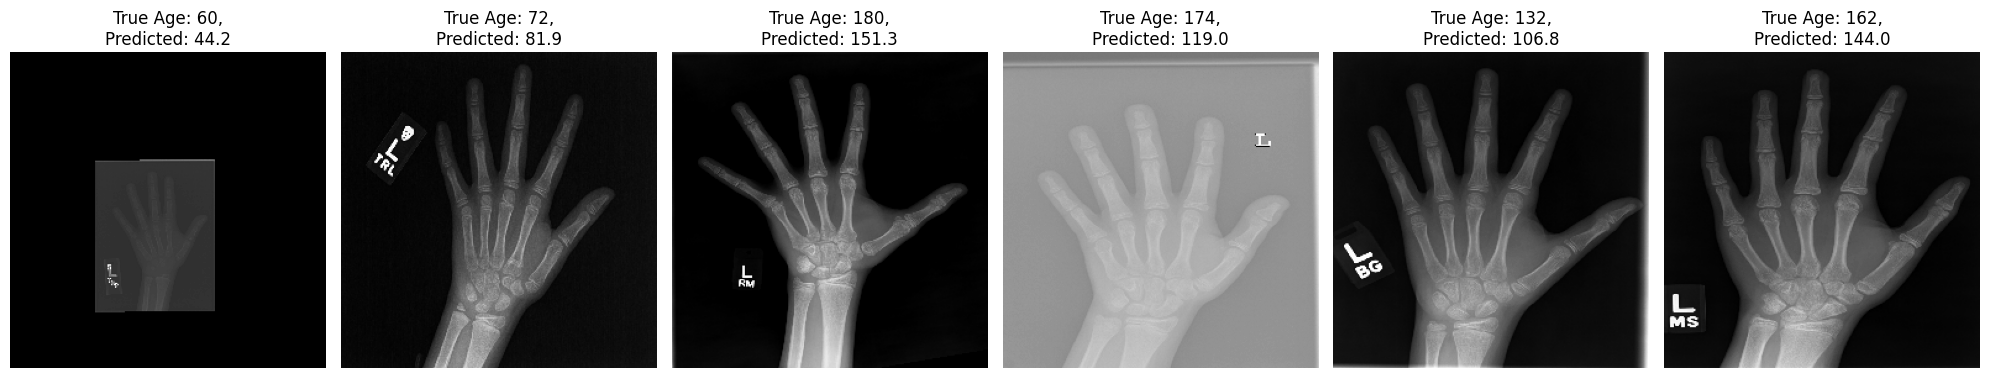

In [11]:
y_pred = new_model.predict(X_test, batch_size=64, verbose=1)

indices = np.array([1, 45, 67, 89, 91, 109])

fig, ax = plt.subplots(1, 6, figsize=(20, 20))

for i, axis in zip(indices, ax.flatten()):
    axis.imshow(X_test[i, :, :, 0], cmap="gray")
    axis.set_title(f"True Age: {y_test[i]},\nPredicted: {y_pred[i][0]:.1f}")
    axis.axis("off")

plt.tight_layout()
plt.show()


In [12]:
data_augmentation = dict(rotation_range=180,
                        zoom_range = 0.25,
                        brightness_range = [0.2,0.5],
                        width_shift_range = 0.2,
                        height_shift_range = 0.2,
                        horizontal_flip = True,
                        shear_range = 0.05,
                        fill_mode = "nearest")

train_generator = ImageDataGenerator(rescale=1/255, preprocessing_function = preprocess_input, **data_augmentation)
test_val_generator = ImageDataGenerator(rescale=1/255, preprocessing_function = preprocess_input)

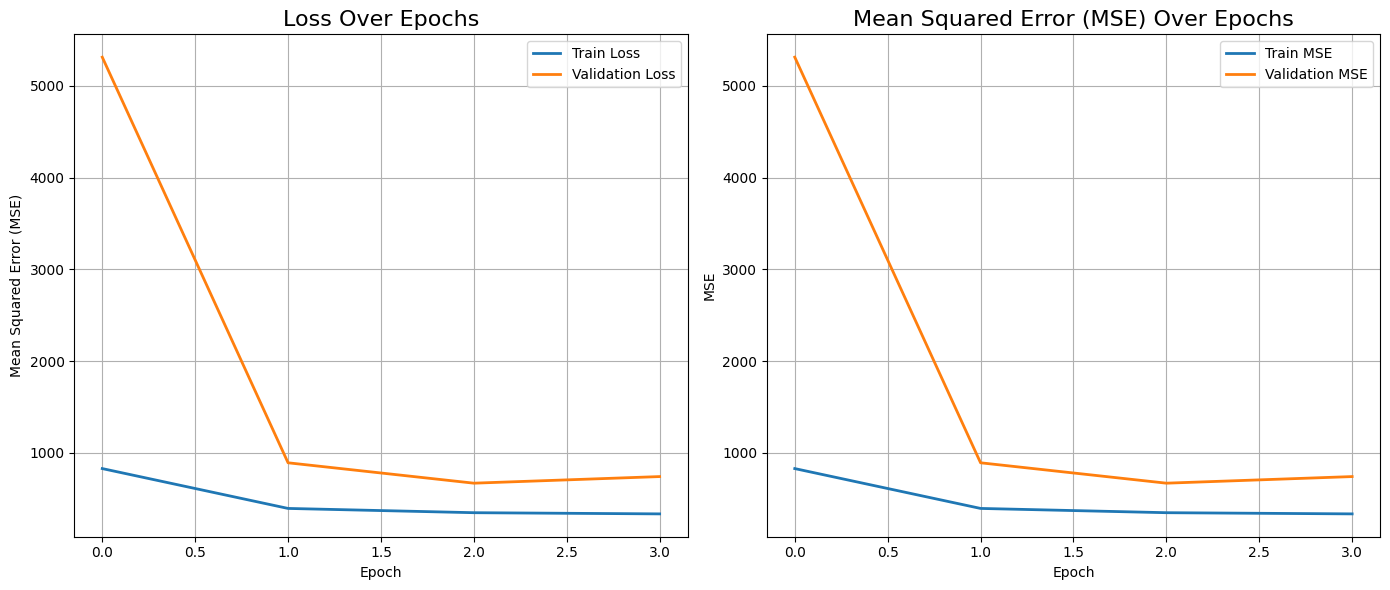

In [13]:
import matplotlib.pyplot as plt

def plot_model_performance(history):
    # Plot Training & Validation Loss
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Loss Over Epochs', fontsize=16)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.grid(True)

    # Plot Training & Validation MSE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mse'], label='Train MSE', linewidth=2)
    plt.plot(history.history['val_mse'], label='Validation MSE', linewidth=2)
    plt.title('Mean Squared Error (MSE) Over Epochs', fontsize=16)
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Usage: Call this after training the model
plot_model_performance(history)


In [14]:
new_model.save("bone_age_model.h5")
print("Model saved as bone_age_model.h5")


Model saved as bone_age_model.h5


MODEL EVALUATION